# Strano et al. (2023) — Sponge Microbiome under Marine Heatwave Conditions, Reproduced with Pyloseq

**Reference:** Strano F, Stauffer JB, Mills SC, Boissin E, Planes S, Lecellier G, Doo SS, Hédouin L (2023). *Marine heatwaves affect the microbiome and development of the sponge *Halisarca caerulea*.* **Science of the Total Environment** 870: 161864. DOI: [10.1016/j.scitotenv.2023.161864](https://doi.org/10.1016/j.scitotenv.2023.161864).

The study examined how marine heatwave (MHW) conditions affect the microbiome of *Halisarca caerulea* sponges and their offspring in Wellington Harbour (New Zealand). Adults exposed to thermal stress showed tissue regression and necrosis; larvae produced by stressed sponges showed altered survival and development. 16S rRNA amplicon sequencing (V4 region, 31 samples) revealed shifts in microbiome composition across adult life-stage conditions and larval cohorts.

This notebook reproduces the main phyloseq analyses from the paper's R scripts (`Strano_et_al_SCRIPTS.R`, `MICROBIOLOGY.R`) using Python and `pyloseq`. 


---
### Setup

In [6]:
import warnings

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import chi2_contingency, logistic
from skbio.stats.distance import permanova, permdisp
from skbio.diversity import beta_diversity
from statsmodels.duration.survfunc import SurvfuncRight, survdiff
from statsmodels.formula.api import logit, mixedlm

from pyloseq import (
    OtuTable,
    Phyloseq,
    SampleData,
    TaxTable,
    estimate_richness,
    multi_tax_test,
    ordinate,
    plot_bar,
    plot_heatmap,
    plot_ordination,
    plot_richness,
    psmelt,
    subset_samples,
    subset_taxa,
    tax_glom,
    transform_sample_counts,
)

warnings.filterwarnings("ignore")

DATA = "data/strano"
RNG = np.random.default_rng(42)

---
### Microbiome Analysis — Phyloseq

#### Load Data and Build the Phyloseq Object

All microbiome data are stored in `phyloseq.xlsx` with three sheets:

| Sheet | Contents |
|-------|----------|
| `OTU matrix` | 1992 ZOTUs × 31 samples (raw read counts) |
| `Taxonomy table` | GTDB r95 taxonomy: Phylum → Species per ZOTU |
| `Samples` | Sample metadata: Stage (Adult/Larvae), Condition (Normal/Regression/Necrosis) |

Sample names encode life stage, parental condition, and replicate number (e.g. `Adult_DRegression_1`). Larvae from thermally stressed parents are labelled `Larvae_Regression_*`; their `Condition` is "Regression" in the metadata.

**No phylogenetic tree is available** — sequences were denoised with UNOISE3 into zero-radius OTUs (ZOTUs / ASVs) and classified against the GTDB r95 database, but not placed on a reference tree. UniFrac distances are therefore not applicable; Bray-Curtis and Sorensen are used for beta diversity.

| R call | pyloseq equivalent |
|--------|-------------------|
| `otu_table(otu_mat, taxa_are_rows=TRUE)` | `OtuTable(otu_mat, taxa_are_rows=True)` |
| `tax_table(tax_mat)` | `TaxTable(tax_mat)` |
| `sample_data(samples_df)` | `SampleData(samples_df)` |
| `phyloseq(OTU, TAX, samples)` | `Phyloseq(otu=..., tax=..., sam=...)` |

In [7]:
# R: otu_mat <- read_excel("phyloseq.xlsx", sheet="OTU matrix")
#    tax_mat <- read_excel("phyloseq.xlsx", sheet="Taxonomy table")
#    samples_df <- read_excel("phyloseq.xlsx", sheet="Samples")
otu_mat = pd.read_excel(f"{DATA}/phyloseq.xlsx", sheet_name="OTU matrix", index_col=0)
tax_mat = pd.read_excel(f"{DATA}/phyloseq.xlsx", sheet_name="Taxonomy table", index_col=0)
samples_df = pd.read_excel(f"{DATA}/phyloseq.xlsx", sheet_name="Samples", index_col=0)

print(f"OTU matrix:     {otu_mat.shape[0]} ZOTUs × {otu_mat.shape[1]} samples")
print(f"Taxonomy table: {tax_mat.shape[0]} ZOTUs × {tax_mat.shape[1]} ranks ({list(tax_mat.columns)})")
print(f"Sample data:    {samples_df.shape[0]} samples × {samples_df.shape[1]} variables")
print()
print("ZOTUs with taxonomy:", len(set(otu_mat.index) & set(tax_mat.index)),
      f"(of {len(otu_mat.index)} total; {len(otu_mat.index)-len(set(otu_mat.index)&set(tax_mat.index))} lack taxonomy)")
print()
samples_df

OTU matrix:     1992 ZOTUs × 31 samples
Taxonomy table: 1748 ZOTUs × 6 ranks (['phylum', 'class', 'order', 'family', 'genus', 'species'])
Sample data:    31 samples × 2 variables

ZOTUs with taxonomy: 1748 (of 1992 total; 244 lack taxonomy)



,Stage,Condition
sample,,
Adult_Control_1,Adult,Normal
Adult_Control_2,Adult,Normal
Adult_Control_3,Adult,Normal
Adult_Control_4,Adult,Normal
Adult_Control_5,Adult,Normal
Adult_DRegression_1,Adult,Regression
Adult_DRegression_2,Adult,Regression
Adult_DRegression_3,Adult,Regression
Adult_DRegression_4,Adult,Regression


In [8]:
# R: OTU = otu_table(otu_mat, taxa_are_rows=TRUE)
#    TAX = tax_table(tax_mat)
#    samples = sample_data(samples_df)
#    carbom <- phyloseq(OTU, TAX, samples)
carbom = Phyloseq(
    otu=OtuTable(otu_mat, taxa_are_rows=True),
    tax=TaxTable(tax_mat),
    sam=SampleData(samples_df),
)

print(f"Phyloseq object: {carbom.ntaxa} taxa × {carbom.nsamples} samples")
print(f"  Ranks:    {carbom.rank_names}")
print(f"  Variables: {carbom.sample_variables}")
print()
print("Sequencing depth per sample:")
sums = carbom.sample_sums()
print(f"  Median: {sums.median():.0f}  |  Min: {sums.min()}  |  Max: {sums.max()}")

Phyloseq object: 1748 taxa × 31 samples
  Ranks:    ['phylum', 'class', 'order', 'family', 'genus', 'species']
  Variables: ['Stage', 'Condition']

Sequencing depth per sample:
  Median: 63766  |  Min: 39029  |  Max: 82689


#### Rarefaction Curves

Rarefaction curves assess sequencing saturation: the plateau of the observed richness vs. sequencing depth curve indicates that most diversity has been captured.

| R call | Python equivalent |
|--------|-------------------|
| `rarecurve(t(otu_table(carbom)), step=10, cex=0.10)` | Manual subsampling + matplotlib |

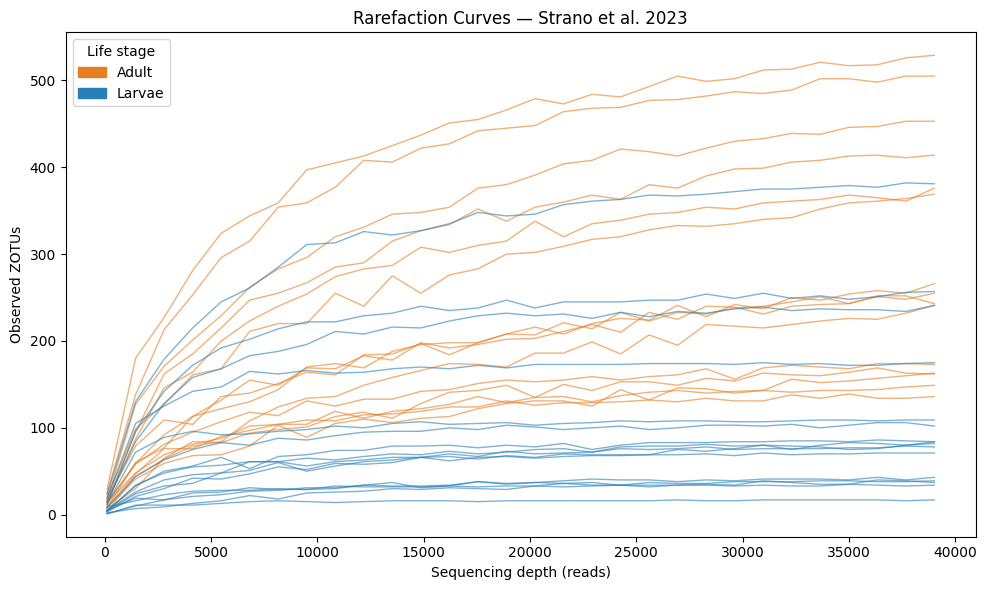

Minimum sequencing depth: 39029
All samples appear to saturate well before 39029 reads — sequencing depth is adequate.


In [9]:
def rarefaction_curve(counts_int, depths, n_reps=1):
    """Expected observed richness at each subsampling depth (random subsampling without replacement)."""
    total = counts_int.sum()
    taxa_pool = np.repeat(np.arange(len(counts_int)), counts_int)
    results = []
    for d in depths:
        if d > total:
            break
        obs_list = []
        for _ in range(n_reps):
            samp = RNG.choice(taxa_pool, size=d, replace=False)
            obs_list.append(len(np.unique(samp)))
        results.append((d, np.mean(obs_list)))
    return np.array(results)


# R: rarecurve(t(otu_table(carbom)), step=10, cex=0.10)
counts_df = otu_mat.loc[carbom.taxa_names]  # only taxa in the Phyloseq object
sample_meta = samples_df.loc[carbom.sample_names]

min_depth = int(carbom.sample_sums().min())
depths = np.linspace(100, min_depth, 30, dtype=int)

# Color by Stage
palette = {"Adult": "#e67e22", "Larvae": "#2980b9"}
cond_palette = {"Normal": "#27ae60", "Regression": "#e74c3c", "Necrosis": "#8e44ad"}

fig, ax = plt.subplots(figsize=(10, 6))
for sample in carbom.sample_names:
    stage = sample_meta.loc[sample, "Stage"]
    cnts = counts_df[sample].values.astype(int)
    curve = rarefaction_curve(cnts, depths)
    if len(curve):
        ax.plot(curve[:, 0], curve[:, 1], color=palette[stage], alpha=0.6, linewidth=1)

# Legend
handles = [mpatches.Patch(color=c, label=l) for l, c in palette.items()]
ax.legend(handles=handles, title="Life stage")
ax.set_xlabel("Sequencing depth (reads)")
ax.set_ylabel("Observed ZOTUs")
ax.set_title("Rarefaction Curves — Strano et al. 2023")
plt.tight_layout()
plt.show()

print(f"Minimum sequencing depth: {min_depth}")
print(f"All samples appear to saturate well before {min_depth} reads — sequencing depth is adequate.")

#### Normalize and Prepare Analysis Datasets

Counts are normalized to the **median sequencing depth** across samples (robust to outlier depths):

```
normalized_count = round(median_depth × raw_count / sample_total)
```

Three sub-datasets are created:

| Dataset | Samples | Description |
|---------|---------|-------------|
| `carbom_full` | 31 | All samples |
| `carbom_adult` | 15 | Adults only (Normal, Regression, Necrosis) |
| `carbom_larvae` | 16 | Larvae only (offspring of Normal or Regression parents) |

| R call | pyloseq equivalent |
|--------|--------------------|
| `total = median(sample_sums(carbom))` | `carbom.sample_sums().median()` |
| `transform_sample_counts(carbom, standf)` | `transform_sample_counts(carbom, lambda x: ...)` |
| `subset_samples(carbom, Stage=="Adult")` | `subset_samples(carbom, lambda s: s["Stage"]=="Adult")` |

In [10]:
# R: total = median(sample_sums(carbom))
#    standf = function(x, t=total) round(t * (x / sum(x)))
#    carbom = transform_sample_counts(carbom, standf)
median_depth = int(carbom.sample_sums().median())

carbom_norm = transform_sample_counts(
    carbom,
    lambda x: np.round(median_depth * x / x.sum()).astype(int)
)
print(f"Median depth: {median_depth}")
print(f"Normalized Phyloseq: {carbom_norm}")

# R: carbom.adult <- subset_samples(carbom, Stage == "Adult")
#    carbom.larvae <- subset_samples(carbom, Stage == "Larvae")
carbom_adult = subset_samples(carbom_norm, lambda s: s["Stage"] == "Adult")
carbom_larvae = subset_samples(carbom_norm, lambda s: s["Stage"] == "Larvae")

print(f"Adults:  {carbom_adult.nsamples} samples — Conditions: {list(carbom_adult.sample_data.to_frame()['Condition'].unique())}")
print(f"Larvae:  {carbom_larvae.nsamples} samples — Conditions: {list(carbom_larvae.sample_data.to_frame()['Condition'].unique())}")

Median depth: 63766
Normalized Phyloseq: Phyloseq(1748 taxa × 31 samples)
  sample_data: 2 variables
  tax_table:   6 ranks
Adults:  15 samples — Conditions: ['Normal', 'Regression', 'Necrosis']
Larvae:  16 samples — Conditions: ['Normal', 'Regression']


#### Beta Diversity — Sørensen Dissimilarity and Dispersion

Sørensen dissimilarity (presence/absence, equivalent to the Dice coefficient for binary data) quantifies how differently two communities are assembled. We compare:

1. **Adults vs. Larvae** — whole-community comparison across life stages
2. **Adults**: Normal vs. Regression vs. Necrosis — effect of adult condition
3. **Larvae**: Normal vs. Regression — effect of parental sponge condition

**PERMDISP** (equivalent to R's `betadisper + permutest`) tests whether within-group multivariate dispersion differs between groups.

| R call | Python equivalent |
|--------|-------------------|
| `beta.pair(presabs, index.family="sorensen")` | `skbio.diversity.beta_diversity("dice", ...)` |
| `betadisper(dist, group)` | `skbio.stats.distance.permdisp(...)` |
| `permutest(bd)` | p-value returned by `permdisp` |

In [ ]:
# ── Convert to presence/absence ──
# R: presabs <- ifelse(datacarb.wide > 0, 1, 0)
from pyloseq import prune_taxa

# Build presence/absence OTU table for the full dataset
otu_full = carbom_norm.otu_table.to_dataframe()  # taxa × samples

# Remove taxa with zero reads across all samples before presence/absence
otu_pa = (otu_full > 0).astype(int)
otu_pa = otu_pa.loc[otu_pa.sum(axis=1) > 0]

# ── Sørensen dissimilarity ──
# R: dist <- beta.pair(presabs, index.family="sorensen")[[3]]  (overall Sørensen)
# Note: Sørensen = Dice coefficient for binary (presence/absence) data
sample_ids = list(carbom_norm.sample_names)
sorensen = beta_diversity("dice", otu_pa.T.values, ids=sample_ids)
print("Sørensen dissimilarity matrix:", sorensen.shape)
print()

# ── 1. Adults vs. Larvae ──
# R: bd <- betadisper(dist, datacarb.factwide$Stage)
meta_full = carbom_norm.sample_data.to_frame().loc[sample_ids]
result_stage = permdisp(sorensen, meta_full["Stage"], permutations=999)
print("PERMDISP — Adults vs. Larvae (Sørensen):")
print(result_stage)
print()

# ── 2. Adults: Normal vs. Regression vs. Necrosis ──
adult_ids = [s for s in sample_ids if meta_full.loc[s, "Stage"] == "Adult"]
sorensen_adult = sorensen.filter(adult_ids)
meta_adult = meta_full.loc[adult_ids]
result_adult = permdisp(sorensen_adult, meta_adult["Condition"], permutations=999)
print("PERMDISP — Adult conditions (Sørensen):")
print(result_adult)
print()

# ── 3. Larvae: Normal vs. Regression ──
larvae_ids = [s for s in sample_ids if meta_full.loc[s, "Stage"] == "Larvae"]
sorensen_larvae = sorensen.filter(larvae_ids)
meta_larvae = meta_full.loc[larvae_ids]
result_larvae = permdisp(sorensen_larvae, meta_larvae["Condition"], permutations=999)
print("PERMDISP — Larval conditions (Sørensen):")
print(result_larvae)

#### NMDS Ordination — Bray-Curtis Dissimilarity

Non-metric multidimensional scaling (NMDS) with Bray-Curtis dissimilarity on log-transformed counts (`log(x + 1)`). Three ordinations are computed and plotted:

1. **Full dataset** — Adult vs. Larvae
2. **Adults only** — Normal vs. Regression vs. Necrosis
3. **Larvae only** — offspring from Normal vs. Regression (stressed) parents

Stress < 0.2 indicates an adequate low-dimensional representation. 80% confidence ellipses (t-distribution) follow the paper's original R code.

| R call | pyloseq equivalent |
|--------|--------------------|
| `log(datacarb.wide + 1)` | `transform_sample_counts(carbom, np.log1p)` |
| `vegdist(log_mat, method="bray")` | `distance(carbom_log, "bray")` via `ordinate` |
| `metaMDS(bray, k=2, trymax=100)` | `ordinate(carbom_log, method="NMDS", distance="bray")` |
| `plot_ordination(...)` | `plot_ordination(...)` |

In [5]:
from plotnine import aes, geom_point, ggplot, stat_ellipse, theme_bw, ggtitle, labs, theme, element_text

# ── Log transform ──
# R: datacarb.wide.log <- log(datacarb.wide + 1)
carbom_log = transform_sample_counts(carbom_norm, np.log1p)
carbom_log_adult = subset_samples(carbom_log, lambda s: s["Stage"] == "Adult")
carbom_log_larvae = subset_samples(carbom_log, lambda s: s["Stage"] == "Larvae")

# ── 1. Full dataset NMDS ──
# R: bray <- vegdist(datacarb.wide.log, method="bray")
#    nMDS = metaMDS(bray, k=2, engine="monoMDS", trymax=100, autotransform=F)
print("Running NMDS (full dataset)...")
nmds_full = ordinate(carbom_log, method="NMDS", distance="bray")
print(f"  Stress: {nmds_full.stress:.4f} ({'good' if nmds_full.stress < 0.2 else 'high — interpret with caution'})")

# Extract sample scores + metadata for manual ggplot (enables stat_ellipse)
scores_full = nmds_full.samples.copy()
scores_full = scores_full.join(carbom_norm.sample_data.to_frame())

p_full = (
    ggplot(scores_full, aes(x="NMDS1", y="NMDS2", fill="Stage", color="Stage"))
    + geom_point(size=3, stroke=0.5, shape="o")
    + stat_ellipse(aes(group="Stage"), type="t", level=0.80, geom="polygon", alpha=0.1)
    + theme_bw()
    + ggtitle(f"Fig. 3a — Full dataset (stress = {nmds_full.stress:.3f})")
    + labs(x="NMDS1", y="NMDS2")
    + theme(figure_size=(6, 5))
)
p_full

NameError: name 'carbom_norm' is not defined

Running NMDS (adults)...
  Stress: 0.1925


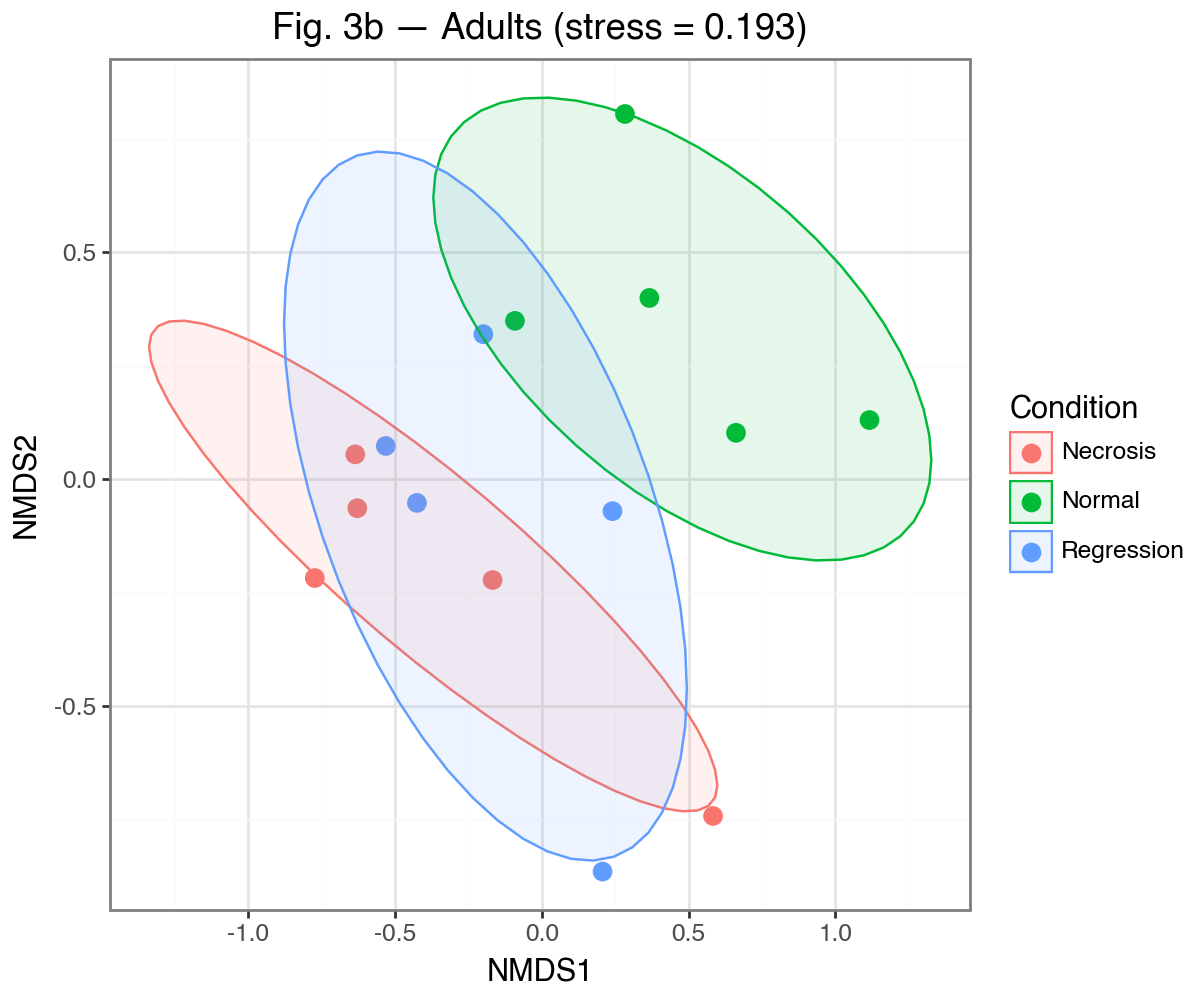

In [15]:
# ── 2. Adults-only NMDS ──
print("Running NMDS (adults)...")
nmds_adult = ordinate(carbom_log_adult, method="NMDS", distance="bray")
print(f"  Stress: {nmds_adult.stress:.4f}")

scores_adult = nmds_adult.samples.copy()
scores_adult = scores_adult.join(carbom_adult.sample_data.to_frame())

p_adult = (
    ggplot(scores_adult, aes(x="NMDS1", y="NMDS2", fill="Condition", color="Condition"))
    + geom_point(size=3, stroke=0.5, shape="o")
    + stat_ellipse(aes(group="Condition"), type="t", level=0.80, geom="polygon", alpha=0.1)
    + theme_bw()
    + ggtitle(f"Fig. 3b — Adults (stress = {nmds_adult.stress:.3f})")
    + labs(x="NMDS1", y="NMDS2")
    + theme(figure_size=(6, 5))
)
p_adult

Running NMDS (larvae)...


  Stress: 0.2099


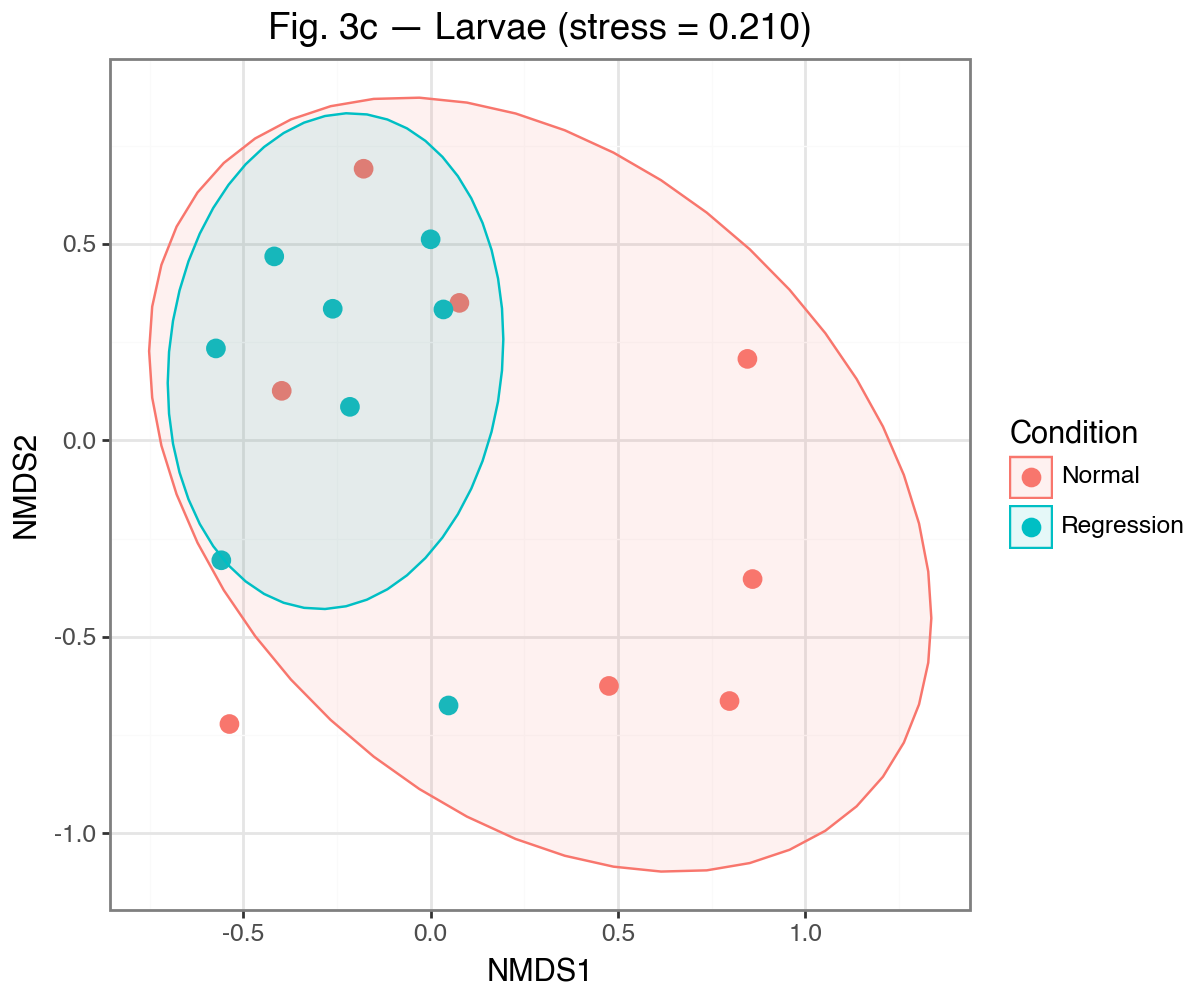

In [16]:
# ── 3. Larvae-only NMDS ──
print("Running NMDS (larvae)...")
nmds_larvae = ordinate(carbom_log_larvae, method="NMDS", distance="bray")
print(f"  Stress: {nmds_larvae.stress:.4f}")

scores_larvae = nmds_larvae.samples.copy()
scores_larvae = scores_larvae.join(carbom_larvae.sample_data.to_frame())

p_larvae = (
    ggplot(scores_larvae, aes(x="NMDS1", y="NMDS2", fill="Condition", color="Condition"))
    + geom_point(size=3, stroke=0.5, shape="o")
    + stat_ellipse(aes(group="Condition"), type="t", level=0.80, geom="polygon", alpha=0.1)
    + theme_bw()
    + ggtitle(f"Fig. 3c — Larvae (stress = {nmds_larvae.stress:.3f})")
    + labs(x="NMDS1", y="NMDS2")
    + theme(figure_size=(6, 5))
)
p_larvae

#### Multivariate Community Structure — PERMANOVA

Does community composition differ significantly between groups? The R script uses `mvabund::manyglm(..., family="negative_binomial")` with Monte Carlo resampling — a model-based approach. No direct Python equivalent exists.

We use **PERMANOVA** (`scikit-bio.stats.distance.permanova`) on Bray-Curtis distances as a well-established non-parametric alternative. PERMANOVA partitions variance in a distance matrix by grouping factors; it tests the same null hypothesis (no difference in community composition between groups) by a different method.

| R call | Python equivalent |
|--------|-------------------|
| `manyglm(mv.FULL ~ Stage, family="negative_binomial")` | `permanova(bray_dm, grouping)` (distance-based) |
| `anova(mod1, resamp="montecarlo")` | 999-permutation PERMANOVA |

**Note:** PERMANOVA is distance-based and sensitive to dispersion differences; `manyglm` is model-based and handles count data directly. Results may differ when groups have unequal dispersion.

In [17]:
from pyloseq import distance as pldistance

# Compute Bray-Curtis distance on log-transformed data
# R: bray <- vegdist(log(datacarb.wide + 1), method="bray")
bray_full = pldistance(carbom_log, method="bray")
bray_adult = pldistance(carbom_log_adult, method="bray")
bray_larvae = pldistance(carbom_log_larvae, method="bray")

# ── 3.6 Full dataset: Adults vs. Larvae ──
# R: mv.FULL <- mvabund(datacarb.wide)
#    mod1 <- manyglm(mv.FULL ~ Stage, family="negative_binomial")
#    anova(mod1, resamp="montecarlo")
groups_full = carbom_norm.sample_data.to_frame().loc[list(bray_full.ids), "Stage"]
res_full = permanova(bray_full, groups_full, permutations=999)
print("PERMANOVA — Adults vs. Larvae (Bray-Curtis):")
print(res_full)
print()

# ── 3.7 Adults: Normal vs. Regression vs. Necrosis ──
# R: mod2 <- manyglm(mv.adult ~ Tissue, family="negative_binomial")
groups_adult = carbom_adult.sample_data.to_frame().loc[list(bray_adult.ids), "Condition"]
res_adult = permanova(bray_adult, groups_adult, permutations=999)
print("PERMANOVA — Adult conditions (Bray-Curtis):")
print(res_adult)
print()

# ── 3.8 Larvae: Normal vs. Regression ──
# R: mod3 <- manyglm(mv.larvae ~ Tissue, family="negative_binomial")
groups_larvae = carbom_larvae.sample_data.to_frame().loc[list(bray_larvae.ids), "Condition"]
res_larvae = permanova(bray_larvae, groups_larvae, permutations=999)
print("PERMANOVA — Larval conditions (Bray-Curtis):")
print(res_larvae)

PERMANOVA — Adults vs. Larvae (Bray-Curtis):
method name               PERMANOVA
test statistic name        pseudo-F
sample size                      31
number of groups                  2
test statistic             6.717094
p-value                       0.001
number of permutations          999
Name: PERMANOVA results, dtype: object

PERMANOVA — Adult conditions (Bray-Curtis):
method name               PERMANOVA
test statistic name        pseudo-F
sample size                      15
number of groups                  3
test statistic             1.870087
p-value                       0.007
number of permutations          999
Name: PERMANOVA results, dtype: object

PERMANOVA — Larval conditions (Bray-Curtis):
method name               PERMANOVA
test statistic name        pseudo-F
sample size                      16
number of groups                  2
test statistic             1.314425
p-value                        0.08
number of permutations          999
Name: PERMANOVA results, dtype

#### Differential Abundance Testing

The paper uses **ANCOMBC** (Analysis of Compositions of Microbiomes with Bias Correction, Lin & Peddada 2020), which corrects for compositional bias inherent in sequencing data. No Python implementation of ANCOMBC exists that mirrors the R version.

We use **`multi_tax_test`** from pyloseq — a pairwise Welch t-test with Benjamini-Hochberg FDR correction — applied to normalized count data. This is a simpler approach that does not apply compositional bias correction.

Six comparisons are run at the species level:

| Comparison | R ANCOMBC equivalent |
|------------|---------------------|
| Adult: Normal vs. Regression | `ancombc(carbom.adult, formula="Condition")` |
| Adult: Normal vs. Necrosis | `ancombc(carbom.adult, formula="Condition")` |
| Larvae: Normal vs. Regression | `ancombc(carbom.larvae, formula="Condition")` |

**Note:** ANCOMBC uses a log-linear model with sample-specific offsets to correct for differential sampling fractions. `multi_tax_test` uses normalized counts without compositional correction. Conclusions about specific taxa may differ between methods.

| R call | pyloseq equivalent |
|--------|--------------------|
| `aggregate_taxa(carbom, "species")` | `tax_glom(carbom, "species")` |
| `subset_samples(carbom, Stage=="Adult")` | `subset_samples(carbom, lambda s: ...)` |
| `ancombc(phyloseq=carbom.adult, formula="Condition", ...)` | `multi_tax_test(ps, "Condition", method="BH")` |

In [18]:
def run_diff_abund(ps, group1, group2, taxrank="species", n_top=20):
    """Run multi_tax_test between two conditions and return significant taxa."""
    # Subset to the two groups being compared
    ps_sub = subset_samples(ps, lambda s: s["Condition"] in [group1, group2])
    # Aggregate to taxrank
    ps_glom = tax_glom(ps_sub, taxrank)
    # Run test
    result = multi_tax_test(ps_glom, grouping_var="Condition", test="t", method="BH")
    result = result.sort_values("adjp")
    n_sig = (result["adjp"] < 0.05).sum()
    return result, n_sig


# ── 3.10–3.11 Adult: Normal vs. Regression ──
# R: carbom.adult <- subset_samples(carbom, Stage=="Adult" & Condition!="Necrosis")
#    out = ancombc(phyloseq=carbom.adult, formula="Condition", ...)
carbom_adult_full = subset_samples(carbom_norm, lambda s: s["Stage"] == "Adult")

res_adult_reg, n_sig_ar = run_diff_abund(carbom_adult_full, "Normal", "Regression")
print(f"Adult Normal vs. Regression ({n_sig_ar} significant at FDR < 0.05):")
print(res_adult_reg[res_adult_reg["adjp"] < 0.05].head(10).to_string())
print()

# ── 3.12–3.13 Adult: Normal vs. Necrosis ──
res_adult_nec, n_sig_an = run_diff_abund(carbom_adult_full, "Normal", "Necrosis")
print(f"Adult Normal vs. Necrosis ({n_sig_an} significant at FDR < 0.05):")
print(res_adult_nec[res_adult_nec["adjp"] < 0.05].head(10).to_string())
print()

# ── 3.14–3.15 Larvae: Normal vs. Regression ──
# R: carbom.larvae <- subset_samples(carbom, Stage=="Larvae")
carbom_larvae_full = subset_samples(carbom_norm, lambda s: s["Stage"] == "Larvae")
res_larvae, n_sig_l = run_diff_abund(carbom_larvae_full, "Normal", "Regression")
print(f"Larvae Normal vs. Regression ({n_sig_l} significant at FDR < 0.05):")
print(res_larvae[res_larvae["adjp"] < 0.05].head(10).to_string())

Adult Normal vs. Regression (0 significant at FDR < 0.05):
Empty DataFrame
Columns: [statistic, rawp, adjp, mean_Normal, mean_Regression]
Index: []



Adult Normal vs. Necrosis (0 significant at FDR < 0.05):
Empty DataFrame
Columns: [statistic, rawp, adjp, mean_Necrosis, mean_Normal]
Index: []



Larvae Normal vs. Regression (0 significant at FDR < 0.05):
Empty DataFrame
Columns: [statistic, rawp, adjp, mean_Normal, mean_Regression]
Index: []


#### Community Composition — Bubble Plot

Relative abundance bubble plot showing species-level composition across all 31 samples. Filtering step: keep species with **mean relative abundance > 0.001** (0.1%) across all samples. Bubble size is square-root transformed relative abundance scaled to the mean sequencing depth.

| R call | pyloseq equivalent |
|--------|--------------------|
| `transform_sample_counts(carbom, function(x) x/sum(x))` | `transform_sample_counts(carbom, lambda x: x/x.sum())` |
| `phyloseq_to_df(carbom, addtax=T, ...)` | `psmelt(carbom)` |
| `gather("Sample", "Abundance", ...)` | `psmelt` already returns long format |
| `aggregate species by sample` | pandas `groupby` |

Species with mean relative abundance > 0.1%: 35 of 1554


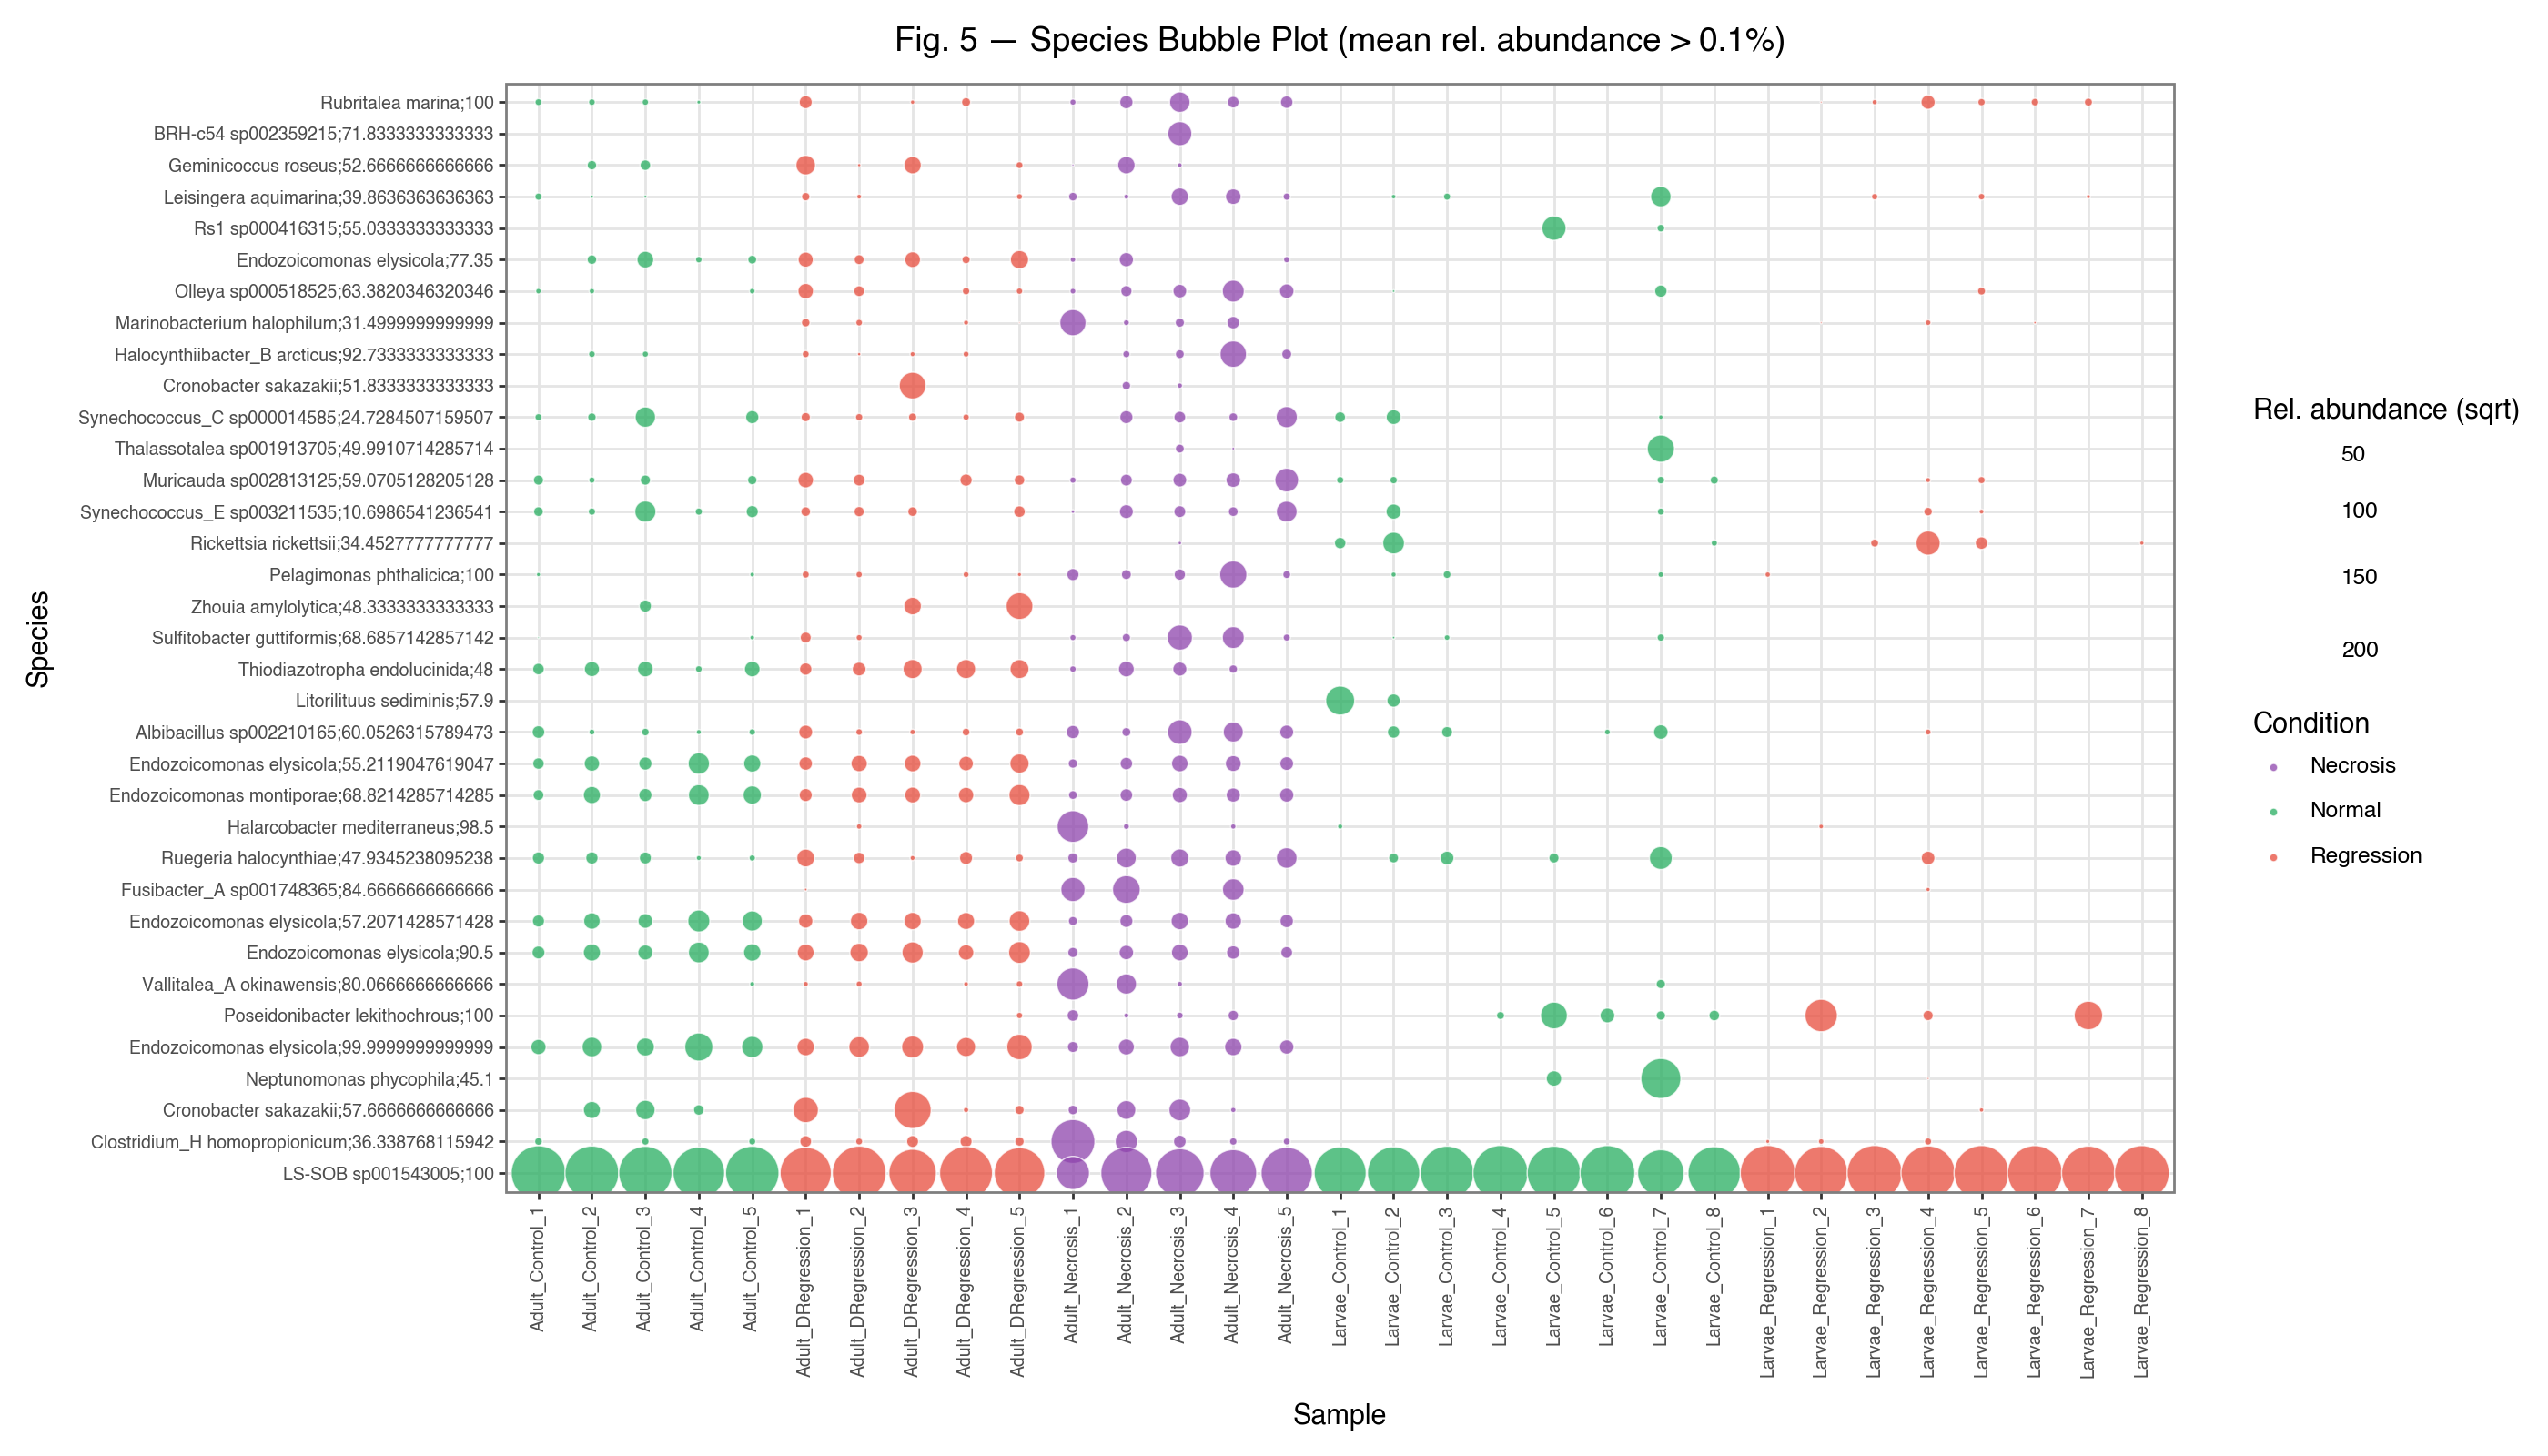

In [19]:
from plotnine import scale_size_area, scale_fill_manual, element_blank, scale_color_manual

# R: carbom = transform_sample_counts(carbom, function(x) x / sum(x))
carbom_rel = transform_sample_counts(carbom, lambda x: x / x.sum())

# R: datacarb = phyloseq_to_df(carbom, addtax=T, ...)
melted = psmelt(carbom_rel)

# R: summarise(Abundance = sum(Abundance)) grouped by species + Sample
species_abundance = (
    melted.groupby(["species", "Sample"], observed=True)["Abundance"]
    .sum()
    .reset_index()
)

# R: filter species with mean abundance > 0.001
species_means = species_abundance.groupby("species", observed=True)["Abundance"].mean()
keep_species = species_means[species_means > 0.001].index.tolist()
print(f"Species with mean relative abundance > 0.1%: {len(keep_species)} of {species_means.shape[0]}")

bubble_data = species_abundance[species_abundance["species"].isin(keep_species)].copy()

# Add Condition metadata
meta = carbom.sample_data.to_frame()
bubble_data["Condition"] = bubble_data["Sample"].map(meta["Condition"])
bubble_data["Stage"] = bubble_data["Sample"].map(meta["Stage"])

# R: datacarbfilt$Abundance = sqrt(datacarbfilt$Abundance * mean_depth)
mean_depth = int(carbom.sample_sums().mean())
bubble_data["AbundanceScaled"] = np.sqrt(bubble_data["Abundance"] * mean_depth)

# Sort species by mean abundance (descending) for y-axis ordering
species_order = (
    bubble_data.groupby("species", observed=True)["Abundance"].mean()
    .sort_values(ascending=False)
    .index.tolist()
)
bubble_data["species"] = pd.Categorical(bubble_data["species"], categories=species_order, ordered=True)

# Sort samples: adults first, then larvae; within each stage by condition
cond_order = {"Normal": 0, "Regression": 1, "Necrosis": 2}
bubble_data["_cond_ord"] = bubble_data["Condition"].map(cond_order)
bubble_data["_stage_ord"] = (bubble_data["Stage"] == "Larvae").astype(int)
sample_order = (
    bubble_data.drop_duplicates("Sample")
    .sort_values(["_stage_ord", "_cond_ord", "Sample"])["Sample"]
    .tolist()
)
bubble_data["Sample"] = pd.Categorical(bubble_data["Sample"], categories=sample_order, ordered=True)

cond_colors = {"Normal": "#27ae60", "Regression": "#e74c3c", "Necrosis": "#8e44ad"}

p_bubble = (
    ggplot(bubble_data[bubble_data["AbundanceScaled"] > 0],
           aes(x="Sample", y="species", fill="Condition", size="AbundanceScaled"))
    + geom_point(alpha=0.75, shape="o", color="white", stroke=0.3)
    + scale_size_area(max_size=12, name="Rel. abundance (sqrt)")
    + scale_fill_manual(values=cond_colors)
    + theme_bw()
    + theme(
        axis_text_x=element_text(rotation=90, size=7),
        axis_text_y=element_text(size=7),
        figure_size=(14, 8),
    )
    + ggtitle("Fig. 5 — Species Bubble Plot (mean rel. abundance > 0.1%)")
    + labs(x="Sample", y="Species")
)
p_bubble